In [2]:
# Creating dataset
import pandas as pd
import numpy as np

np.random.seed(42)

n = 120

data = {
    "age": np.random.randint(18, 65, n),
    "monthly_income": np.random.randint(1000, 10000, n),
    "spending_score": np.random.randint(1, 100, n),
    "city": np.random.choice(["Accra", "Kumasi", "Tema", "Takoradi"], n),
    "subscription_type": np.random.choice(["Basic", "Standard", "Premium"], n)

}

df = pd.DataFrame(data)

# Introduce missing values randomly
for col in df.columns:
    df.loc[df.sample(frac=0.1).index, col] = np.nan

# Introducinng extreme outliers in the monthly income column


In [3]:
df.describe(include="all")
# df.info()

,age,monthly_income,spending_score,city,subscription_type
count,108.000000,108.000000,108.000000,108,108
unique,NaN,NaN,NaN,4,3
top,NaN,NaN,NaN,Kumasi,Basic
freq,NaN,NaN,NaN,28,48
mean,41.148148,5745.750000,47.120370,NaN,NaN
std,14.165784,2560.342402,27.993897,NaN,NaN
min,18.000000,1202.000000,1.000000,NaN,NaN
25%,28.750000,3479.500000,24.750000,NaN,NaN
50%,41.000000,5993.500000,45.000000,NaN,NaN
75%,54.250000,7962.250000,67.000000,NaN,NaN


In [4]:
## Step 1
## Usually to check you data for missing values and how best to clean your data
df.isnull().sum()

age                  12
monthly_income       12
spending_score       12
city                 12
subscription_type    12
dtype: int64

In [5]:
## replacing missing data with median because its often the default safer bet and only because this is a learning test set
df["age"] = df["age"].fillna(df["age"].median())
df["monthly_income"] = df["monthly_income"].fillna(df["monthly_income"].median())
df["spending_score"]=df["spending_score"].fillna(df["spending_score"].median())

## Filling categorical data with the mode
df["city"] = df["city"].fillna(df["city"].mode()[0])
df["subscription_type"] = df["subscription_type"].fillna(df["subscription_type"].mode()[0])

df.isnull().sum()

age                  0
monthly_income       0
spending_score       0
city                 0
subscription_type    0
dtype: int64

## Range
### Intuition
`“What is the spread between the smallest and largest values?”`

### Formula
`Range = Max(x) - Min(x)`



In [8]:
montly_income_range = df["monthly_income"].max() - df["monthly_income"].min()
print(montly_income_range)

8794.0


## Variance
### Intuition
`“How much do the values vary from the mean?”`

### Formula
`σ2=n1​∑i=1n​(xi​−xˉ)2`

Interpretation
- High variance → values are spread out
- Low variance → values are clustered tightly



In [11]:
print(df["monthly_income"].var())

5899879.822899159


### Standard Deviation
Intuition
- “On average, how far are values from the mean?”

In [12]:
print(df["monthly_income"].std())

2428.9668221075312


In [13]:
df[["monthly_income", "spending_score"]].std()

monthly_income    2428.966822
spending_score      26.552626
dtype: float64

### Quick Exercise (Important)

Run this:
```python
df[["age", "monthly_income", "spending_score"]].std()
```
Then Answer:
`Which feature is the most unstable (spread out) and why?`




In [14]:
df[["age", "monthly_income", "spending_score"]].std()

age                 13.432641
monthly_income    2428.966822
spending_score      26.552626
dtype: float64

In [15]:
df["subscription_type"].value_counts(normalize=True)

subscription_type
Basic       0.500000
Standard    0.283333
Premium     0.216667
Name: proportion, dtype: float64

In [1]:
import numpy as np
import pandas as pd

# Dataset A → stable behavior
a = np.array([4, 4, 4, 4, 4])

# Dataset B → unstable/skewed behavior
b = np.array([1, 1, 1, 1, 16])

# Summary statistics
summary = pd.DataFrame({
    'Dataset_A': [
        a.mean(),
        np.median(a),
        a.std()
    ],
    'Dataset_B': [
        b.mean(),
        np.median(b),
        b.std()
    ]
}, index=['Mean', 'Median', 'Std Dev'])

print(summary.round(2))

         Dataset_A  Dataset_B
Mean           4.0        4.0
Median         4.0        1.0
Std Dev        0.0        6.0


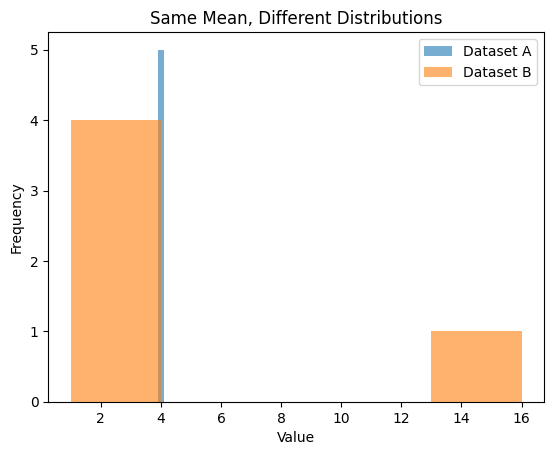

In [2]:
import matplotlib.pyplot as plt

plt.hist(a, alpha=0.6, bins=5, label='Dataset A')
plt.hist(b, alpha=0.6, bins=5, label='Dataset B')

plt.legend()
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Same Mean, Different Distributions')

plt.show()